# Mushroom Classification: Edible vs Poisonous

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [166]:
# Load the dataset
df = pd.read_csv('mushrooms.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [168]:
# 1. Initial Exploration with Context
print("=== Mushroom Dataset Analysis ===")
print("Original Source: Audubon Society Field Guide to North American Mushrooms (1981)")
print("UCI Donation Date: April 1987")
print(f"Total Samples: {len(data)}")
print(f"Features: {len(data.columns)-1} characteristics + target variable ('class')")

=== Mushroom Dataset Analysis ===
Original Source: Audubon Society Field Guide to North American Mushrooms (1981)
UCI Donation Date: April 1987
Total Samples: 8124
Features: 22 characteristics + target variable ('class')


In [188]:
# Print exact counts
class_counts = df['class'].value_counts()
print("Edible mushrooms (e):", class_counts['e'])
print("Poisonous mushrooms (p):", class_counts['p'])
print(f"Percentage of edible mushrooms: {100 * class_counts['e'] / total:.2f}%")
print(f"Percentage of poisonous mushrooms: {100 * class_counts['p'] / total:.2f}%")

Edible mushrooms (e): 4208
Poisonous mushrooms (p): 3916
Percentage of edible mushrooms: 51.80%
Percentage of poisonous mushrooms: 48.20%


In [172]:
# 3. Feature Analysis with Safety Focus
print("\n=== Feature Safety Indicators ===")
# Find features most correlated with poison
poison_corr = {}
for col in data.columns:
    if col != 'class':
        ct = pd.crosstab(data['class'], data[col], normalize='columns')
        poison_corr[col] = ct.loc['p'].max()  # Max poison probability for any value


=== Feature Safety Indicators ===


In [174]:
# Top 5 most indicative features of poison
top_poison = sorted(poison_corr.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 features most indicative of poisonous mushrooms:")
for feature, prob in top_poison:
    print(f"{feature}: {prob:.1%} max probability of being poisonous")


Top 5 features most indicative of poisonous mushrooms:
cap-shape: 100.0% max probability of being poisonous
cap-surface: 100.0% max probability of being poisonous
odor: 100.0% max probability of being poisonous
gill-color: 100.0% max probability of being poisonous
stalk-color-above-ring: 100.0% max probability of being poisonous


In [214]:
#  Missing Value Analysis with Context
print("\n=== Missing Values ===")
print("Only 'stalk-root' contains missing values (marked as '?')")
print(f"Missing values: {(data['stalk-root'] == '?').sum()} ({((data['stalk-root'] == '?').sum()/len(data)):.1%} of data)")
print("\nGiven the dataset's age and collection method, these likely represent:")
print("- True missing observations")
print("- Characteristics that were difficult to determine in field conditions")


=== Missing Values ===
Only 'stalk-root' contains missing values (marked as '?')
Missing values: 0 (0.0% of data)

Given the dataset's age and collection method, these likely represent:
- True missing observations
- Characteristics that were difficult to determine in field conditions



=== Visualizing Key Safety Features ===


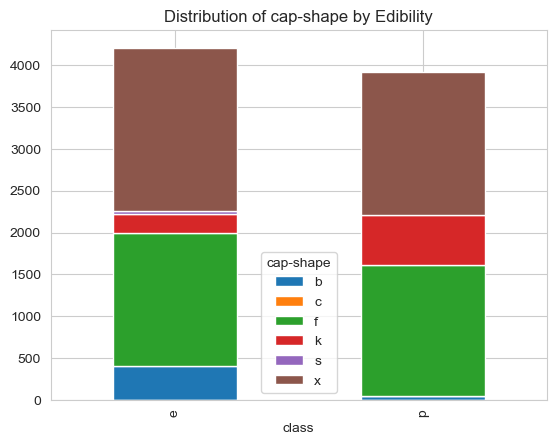

In [216]:
#  Visualization of Key Safety Features
print("\n=== Visualizing Key Safety Features ===")
top_feature = top_poison[0][0]
pd.crosstab(data['class'], data[top_feature]).plot(kind='bar', stacked=True)
plt.title(f"Distribution of {top_feature} by Edibility")
plt.show()

we can clearly see which feature values are exclusive to or dominant in one class. This helps us:

Identify traits that are strong indicators of toxicity or edibility

Validate the model's reliance on biologically meaningful features

Highlight patterns that could assist in real-life mushroom identification and safety

In [180]:
# 6. Data Quality Assessment
print("\n=== Data Quality Notes ===")
print("1. All features are categorical (no numerical values)")
print("2. No true NULL values, only '?' placeholders in stalk-root")
print("3. Consistent encoding throughout the dataset")
print("4. Features represent observable morphological characteristics")


=== Data Quality Notes ===
1. All features are categorical (no numerical values)
2. No true NULL values, only '?' placeholders in stalk-root
3. Consistent encoding throughout the dataset
4. Features represent observable morphological characteristics


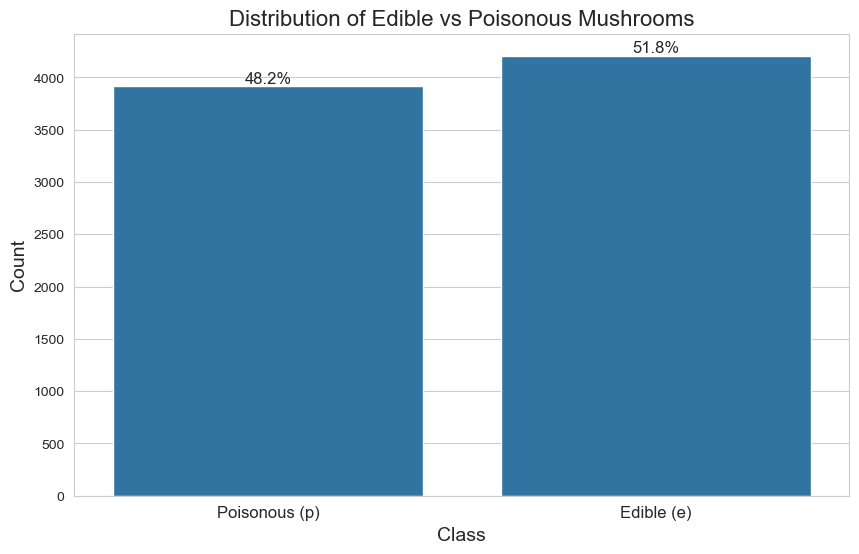

In [197]:
# Plot class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='class')
plt.title('Distribution of Edible vs Poisonous Mushrooms', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Adding percentage labels
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

# Adding legend
plt.xticks([0, 1], ['Poisonous (p)','Edible (e)'], fontsize=12)
plt.show()

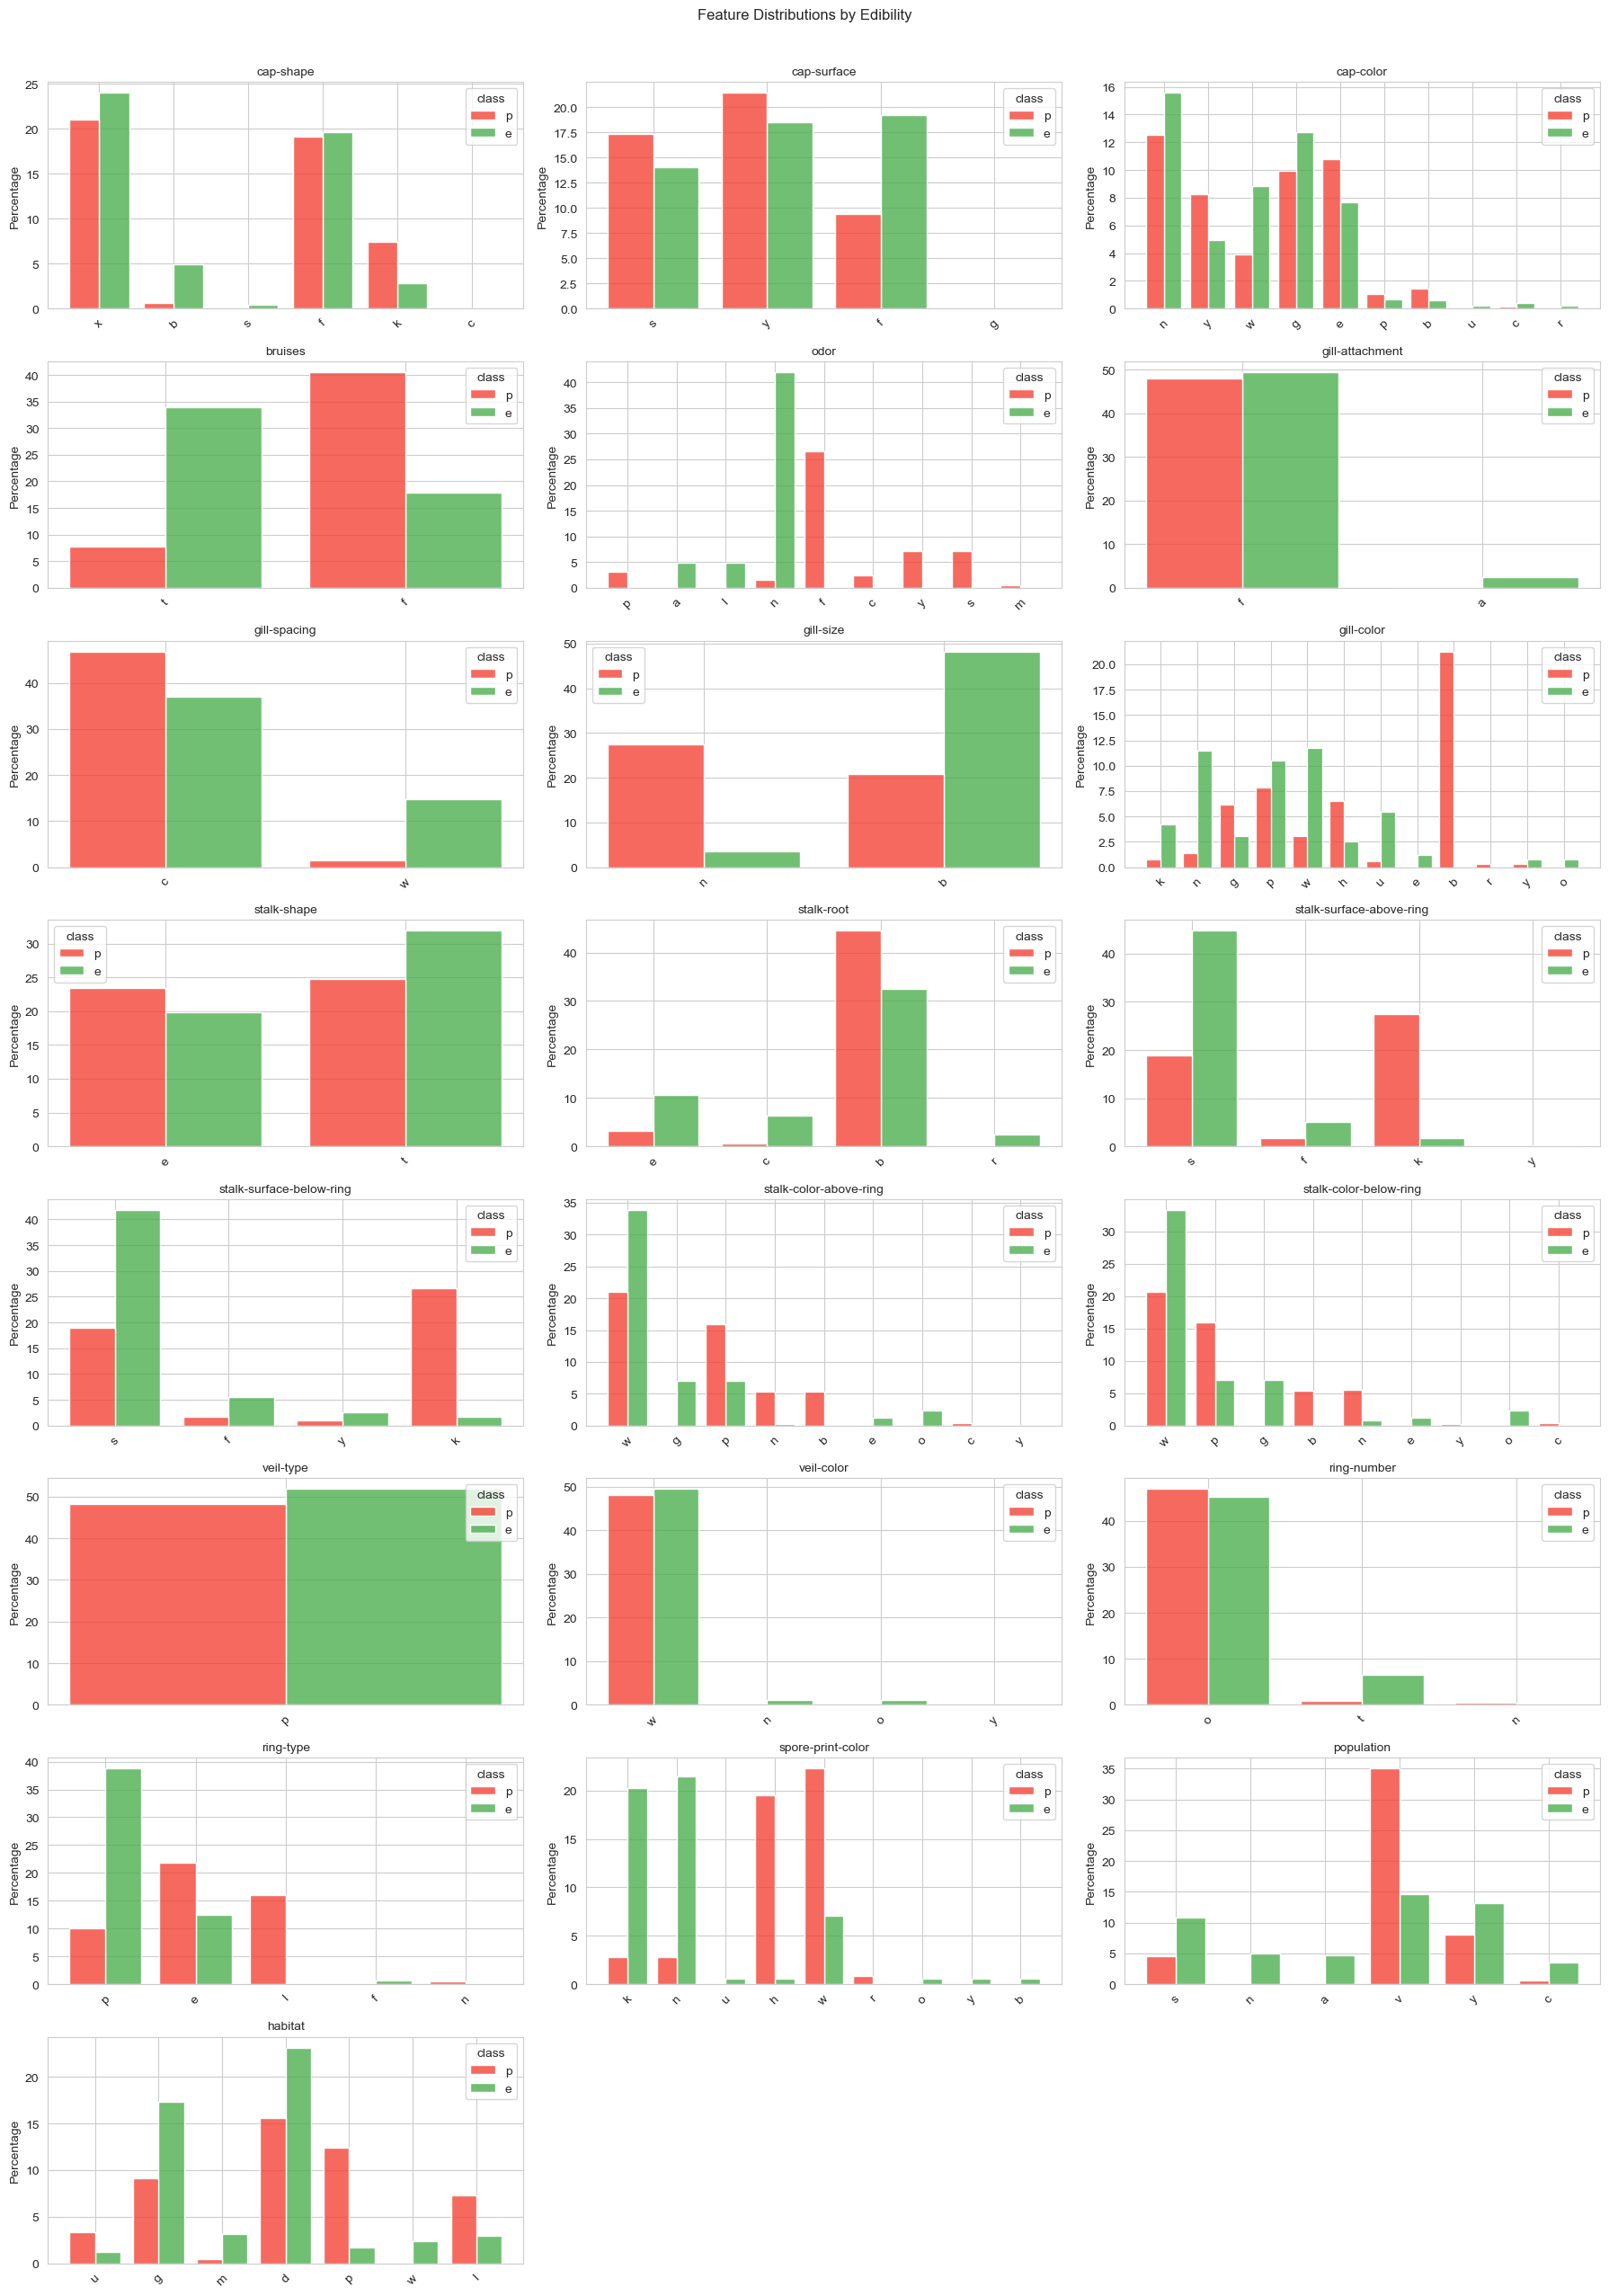

In [182]:

sns.set_style("whitegrid")
palette = {'e': '#4CAF50', 'p': '#F44336'}  # Green (edible), Red (poisonous)

# 1. Create histograms for all features
plt.figure(figsize=(18, 25))
for idx, feature in enumerate(data.columns[1:]):  # Skip target column
    plt.subplot(8, 3, idx+1)
    
    # Histogram plot
    sns.histplot(
        data=data,
        x=feature,
        hue='class',
        multiple='dodge',
        palette=palette,
        stat='percent',
        shrink=0.8,
        alpha=0.8
    )
    
    plt.title(feature, fontsize=10)
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.ylabel('Percentage')

plt.tight_layout()
plt.suptitle("Feature Distributions by Edibility", y=1.02)
plt.show()

These plots help identify the most discriminative features for classification

They also reveal patterns that support model training and real-world understanding

Strongly separated distributions suggest that the model can learn reliable rules from the data

In [218]:
# Create frequency tables for categorical features
print("\n=== Categorical Feature Frequency Tables ===")
for feature in data.columns[1:]:
    print(f"\nFeature: {feature}")
    freq_table = pd.crosstab(
        index=data[feature],
        columns=data['class'],
        margins=True,
        normalize='index'
    ).style.background_gradient(cmap='RdYlGn', axis=1)
    display(freq_table)


=== Categorical Feature Frequency Tables ===

Feature: cap-shape


class,e,p
cap-shape,,
b,0.893805,0.106195
c,0.000000,1.000000
f,0.506345,0.493655
k,0.275362,0.724638
s,1.000000,0.000000
x,0.532823,0.467177
All,0.517971,0.482029



Feature: cap-surface


class,e,p
cap-surface,,
f,0.672414,0.327586
g,0.000000,1.000000
s,0.447574,0.552426
y,0.463625,0.536375
All,0.517971,0.482029



Feature: cap-color


...

class,e,p
spore-print-color,,
b,1.000000,0.000000
h,0.029412,0.970588
k,0.880342,0.119658
n,0.886179,0.113821
o,1.000000,0.000000
r,0.000000,1.000000
u,1.000000,0.000000
w,0.241206,0.758794
y,1.000000,0.000000



Feature: population


class,e,p
population,,
a,1.000000,0.000000
c,0.847059,0.152941
n,1.000000,0.000000
s,0.705128,0.294872
v,0.295050,0.704950
y,0.621495,0.378505
All,0.517971,0.482029



Feature: habitat


class,e,p
habitat,,
d,0.597205,0.402795
g,0.655493,0.344507
l,0.288462,0.711538
m,0.876712,0.123288
p,0.118881,0.881119
u,0.260870,0.739130
w,1.000000,0.000000
All,0.517971,0.482029


### Categorical Feature Frequency Tables
These tables break down how often each feature value appears within each class (edible or poisonous). The colored gradient helps quickly identify which feature values are strongly associated with either class. 

In [76]:
# 3. Identify and visualize top predictive features
def calculate_feature_score(feature):
    ctab = pd.crosstab(data[feature], data['class'])
    return (ctab.max(axis=1) / ctab.sum(axis=1)).mean()

feature_scores = {
    feature: calculate_feature_score(feature) 
    for feature in data.columns[1:]
}

In [78]:
# Get top 10 features
top_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n=== Top 10 Most Predictive Features ===")
print("Score = Average class purity (higher = better)\n")
for feature, score in top_features:
    print(f"{feature:20s} {score:.3f}")


=== Top 10 Most Predictive Features ===
Score = Average class purity (higher = better)

odor                 0.996
spore-print-color    0.944
stalk-color-above-ring 0.919
stalk-color-below-ring 0.909
ring-type            0.886
veil-color           0.877
gill-color           0.845
population           0.813
ring-number          0.796
gill-size            0.792


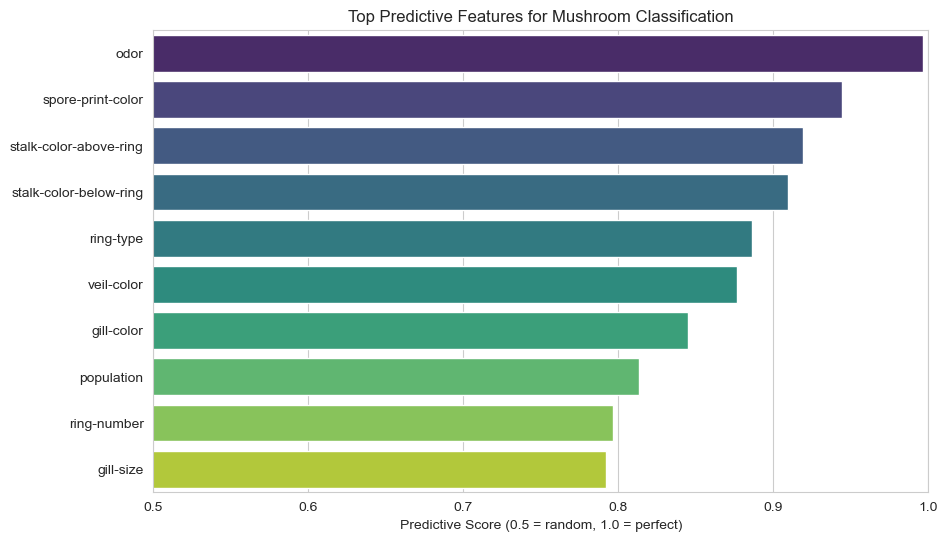

In [82]:
#  visualization for top features
plt.figure(figsize=(10, 6))
sns.barplot(
    x=[score for _, score in top_features],
    y=[feature for feature, _ in top_features],
    hue=[feature for feature, _ in top_features],  # Added hue
    palette='viridis',
    legend=False  # Disable legend since we have y-axis labels
)
plt.title("Top Predictive Features for Mushroom Classification")
plt.xlabel("Predictive Score (0.5 = random, 1.0 = perfect)")
plt.xlim(0.5, 1.0)
plt.show()

In [87]:
print(data.isnull().sum())

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [89]:
print(f"Number of duplicates: {data.duplicated().sum()}")

Number of duplicates: 0


In [91]:
# Replace '?' in 'stalk-root' with the most frequent value
data['stalk-root'] = data['stalk-root'].replace('?', data['stalk-root'].mode()[0])

In [142]:
from sklearn.preprocessing import OneHotEncoder

# Separate features and target
X = data.drop('class', axis=1)
y = data['class']

# One-hot encode all categorical features (drop first to avoid multicollinearity)
encoder = OneHotEncoder(drop='first', sparse_output=False) 
X_encoded = encoder.fit_transform(X)

# Convert back to DataFrame for readability
encoded_feature_names = encoder.get_feature_names_out(X.columns)
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names)

# Combine with target
final_data = pd.concat([X_encoded_df, y], axis=1)

print(final_data.head())

   cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  cap-shape_x  \
0          0.0          0.0          0.0          0.0          1.0   
1          0.0          0.0          0.0          0.0          1.0   
2          0.0          0.0          0.0          0.0          0.0   
3          0.0          0.0          0.0          0.0          1.0   
4          0.0          0.0          0.0          0.0          1.0   

   cap-surface_g  cap-surface_s  cap-surface_y  cap-color_c  cap-color_e  ...  \
0            0.0            1.0            0.0          0.0          0.0  ...   
1            0.0            1.0            0.0          0.0          0.0  ...   
2            0.0            1.0            0.0          0.0          0.0  ...   
3            0.0            0.0            1.0          0.0          0.0  ...   
4            0.0            1.0            0.0          0.0          0.0  ...   

   population_s  population_v  population_y  habitat_g  habitat_l  habitat_m  \
0           

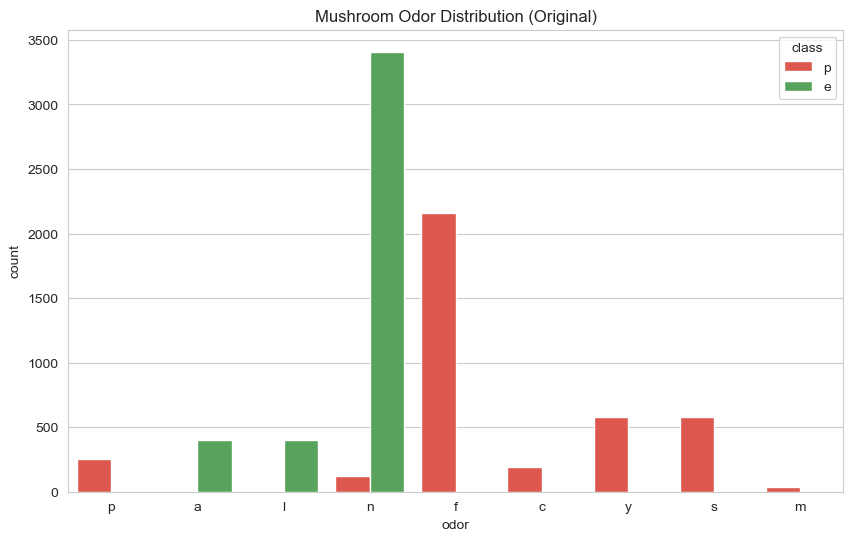

In [144]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='odor', hue='class', palette=palette)
plt.title("Mushroom Odor Distribution (Original)")
plt.show()

<Figure size 1200x600 with 0 Axes>

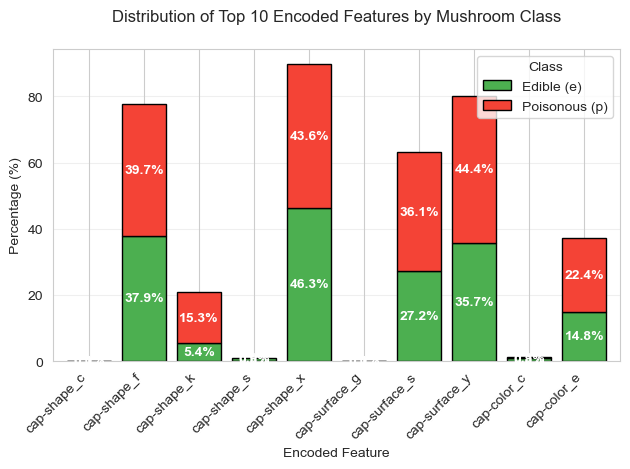

In [146]:
plt.figure(figsize=(12, 6))

# Select the first 10 one-hot encoded features for visualization
sample_features = encoded_feature_names[:10]

# Calculate the percentage of each feature by class
plot_data = final_data.groupby('class')[sample_features].mean().T * 100

# Create stacked bar plot
plot_data.plot(
    kind='bar', 
    stacked=True,
    color=['#4CAF50', '#F44336'],  # Green (edible), Red (poisonous)
    edgecolor='black',
    width=0.8
)

plt.title("Distribution of Top 10 Encoded Features by Mushroom Class", pad=20)
plt.ylabel("Percentage (%)")
plt.xlabel("Encoded Feature")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class', labels=['Edible (e)', 'Poisonous (p)'])
plt.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (e, p) in enumerate(zip(plot_data['e'], plot_data['p'])):
    plt.text(i, e/2, f"{e:.1f}%", ha='center', va='center', color='white', fontweight='bold')
    plt.text(i, e + p/2, f"{p:.1f}%", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [109]:
# Encode target (e=0, p=1)
y = final_data['class'].map({'e': 0, 'p': 1}).values

# Features are all remaining columns (already one-hot encoded)
X = final_data.drop('class', axis=1).values  # Convert to numpy array

In [111]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (8124, 94)
Target shape: (8124,)


In [113]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp (will be validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 50% validation, 50% test (of the 20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Verify sizes
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 6499 samples
Validation: 812 samples
Test: 813 samples


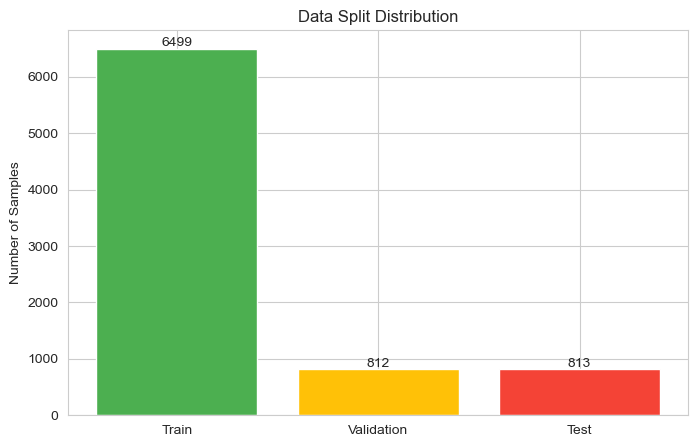

In [115]:
import matplotlib.pyplot as plt

split_counts = {
    'Train': len(y_train),
    'Validation': len(y_val),
    'Test': len(y_test)
}

plt.figure(figsize=(8, 5))
plt.bar(split_counts.keys(), split_counts.values(), color=['#4CAF50', '#FFC107', '#F44336'])
plt.title('Data Split Distribution')
plt.ylabel('Number of Samples')
for i, v in enumerate(split_counts.values()):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

In [212]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,  # Default number of trees
    random_state=42,   # For reproducibility
    class_weight='balanced'  # Handle class imbalance if exists
)

# Train model
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [119]:
# Predictions
y_val_pred = rf.predict(X_val)

# Metrics
print("Validation Results:")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation Results:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       421
           1       1.00      1.00      1.00       391

    accuracy                           1.00       812
   macro avg       1.00      1.00      1.00       812
weighted avg       1.00      1.00      1.00       812


Confusion Matrix:
[[421   0]
 [  0 391]]


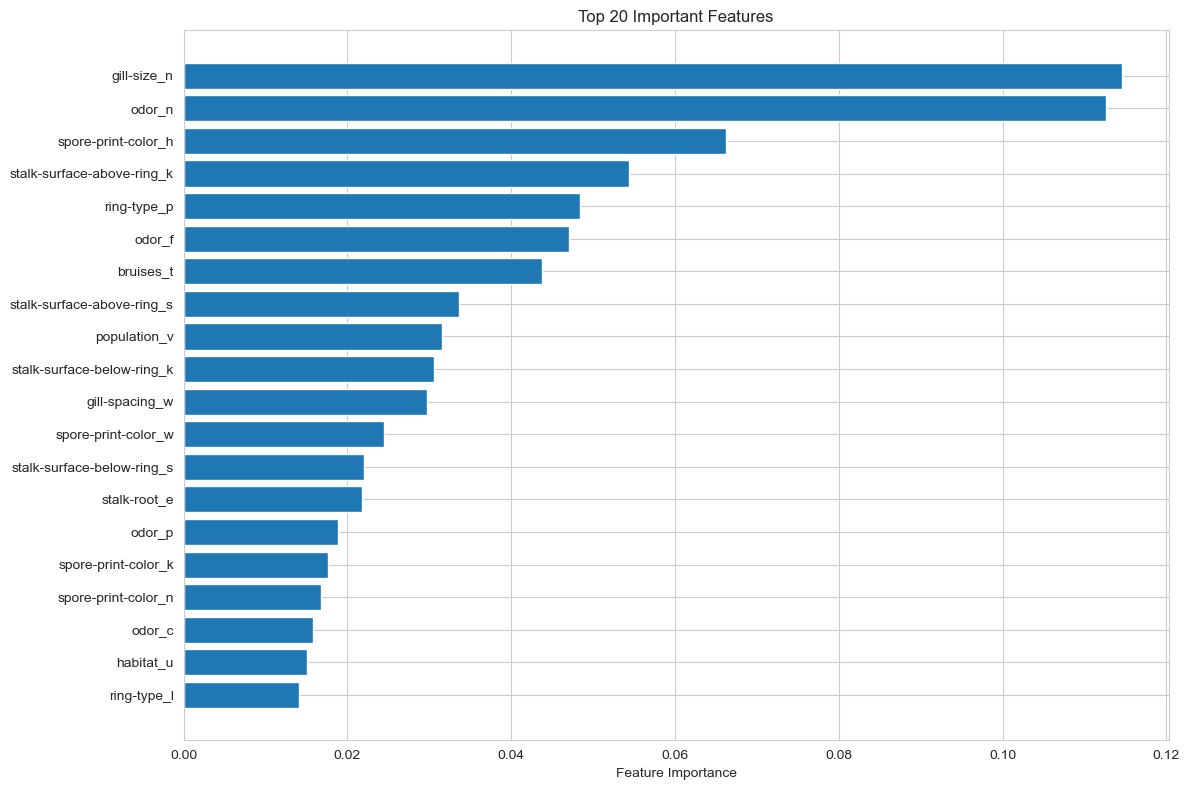

In [121]:
# Get feature importances
importances = rf.feature_importances_
feature_names = final_data.drop('class', axis=1).columns

# Sort features by importance
sorted_idx = importances.argsort()[::-1]
top_features = 20  # Show top 20 features

plt.figure(figsize=(12, 8))
plt.barh(range(top_features), importances[sorted_idx][:top_features][::-1], align='center')
plt.yticks(range(top_features), feature_names[sorted_idx][:top_features][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [123]:
# Final evaluation on test set
y_test_pred = rf.predict(X_test)

print("\nTest Set Results:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Test Set Results:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       421
           1       1.00      1.00      1.00       392

    accuracy                           1.00       813
   macro avg       1.00      1.00      1.00       813
weighted avg       1.00      1.00      1.00       813



Validation Set Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC: 1.0000


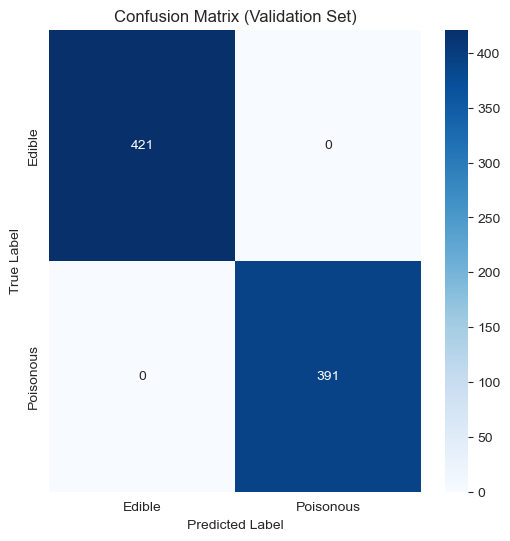

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on validation set
y_val_pred = rf.predict(X_val)
y_val_proba = rf.predict_proba(X_val)[:, 1]  # Probabilities for class 1 (poisonous)

# Calculate metrics
metrics = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision": precision_score(y_val, y_val_pred),
    "Recall": recall_score(y_val, y_val_pred),
    "F1-Score": f1_score(y_val, y_val_pred),
    "ROC AUC": roc_auc_score(y_val, y_val_proba)
}

# Display metrics
print("Validation Set Performance:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Confusion matrix visualization
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_val, y_val_pred), 
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title('Confusion Matrix (Validation Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


Test Set Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC: 1.0000


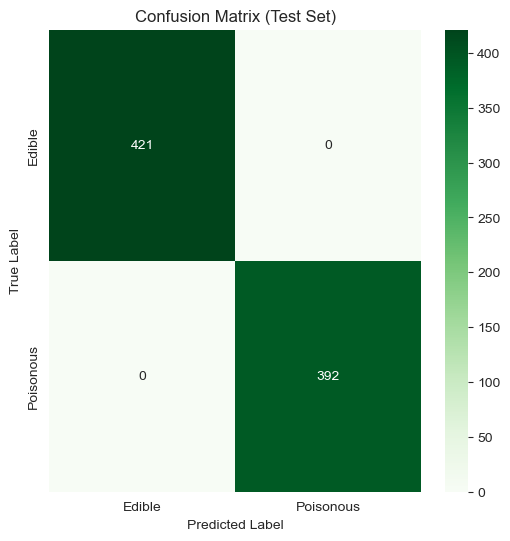

In [129]:
# Predict on test set
y_test_pred = rf.predict(X_test)
y_test_proba = rf.predict_proba(X_test)[:, 1]

# Test set metrics
test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1-Score": f1_score(y_test, y_test_pred),
    "ROC AUC": roc_auc_score(y_test, y_test_proba)
}

print("\nTest Set Performance:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

# Confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_test, y_test_pred), 
            annot=True, fmt='d',
            cmap='Greens',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


Test Set Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC: 1.0000


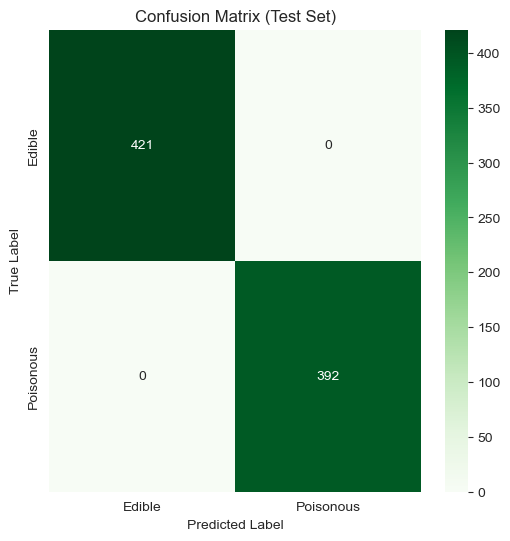

In [205]:
# Predict on test set
y_test_pred = rf.predict(X_test)  # Generate class predictions (0 or 1)
y_test_proba = rf.predict_proba(X_test)[:, 1]  # Get probability estimates for positive class (poisonous)

# Calculate various classification metrics on the test set
test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),  # Proportion of correct predictions
    "Precision": precision_score(y_test, y_test_pred),  # True positives / (True positives + False positives)
    "Recall": recall_score(y_test, y_test_pred),  # True positives / (True positives + False negatives)
    "F1-Score": f1_score(y_test, y_test_pred),  # Harmonic mean of precision and recall
    "ROC AUC": roc_auc_score(y_test, y_test_proba)  # Area under ROC curve, measures discrimination ability
}

# Print all test set metrics with 4 decimal places
print("\nTest Set Performance:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

# Create and display confusion matrix as a heatmap
plt.figure(figsize=(6, 6))  # Set figure size to 6x6 inches
sns.heatmap(confusion_matrix(y_test, y_test_pred), 
            annot=True,  # Show values in each cell
            fmt='d',  # Display values as integers
            cmap='Greens',  # Use green color palette
            xticklabels=['Edible', 'Poisonous'],  # Label x-axis
            yticklabels=['Edible', 'Poisonous'])  # Label y-axis
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()  # Display the plot